<a href="https://colab.research.google.com/github/Andresflorezdev/Global-Environmental-Impact-Dataframe/blob/main/Proyecto_final_clases_virtuales_validacion_cruzada.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import cross_val_predict
from google.colab import files

In [ ]:
# Cargar el dataset
uploaded = files.upload()
df = pd.read_csv("environmental_impact_data.csv", encoding="latin1")
df.head()

Saving environmental_impact_data.csv to environmental_impact_data.csv


,Date,Country,Region,Plastic_Waste_Tons,Plastic_Recycled_Tons,Burned_Waste_Tons,Illegal_Dumping_Cases,Trees_Cut,Deforestation_Area_Ha,Forest_Fires_Reported,CO2_Emissions_Tons,Water_Pollution_Index,Air_Quality_Index,Population_Affected,Government_Interventions,Reforestation_Projects,Waste_Collected_Tons,Plastic_Bans_Enforced,Awareness_Campaigns,Monitoring_Stations
0,2023-08-02,USA,Mountain,2393.68,535.52,842.34,4,904,19.54,1,4120.39,49.15,186.79,72094,1,2,235.16,1,10,35
1,2020-08-16,India,Rural,1494.46,1274.11,881.70,5,835,5.29,3,3725.61,83.97,178.00,50694,3,3,4292.34,0,12,28
2,2020-02-21,China,Urban,1382.28,572.55,577.54,1,859,18.52,1,4242.97,69.80,95.94,26004,1,0,391.70,0,0,29
3,2021-07-17,Russia,Urban,1382.30,258.10,750.74,3,160,7.46,1,3908.78,42.53,103.58,65864,4,3,1699.11,1,12,47
4,2021-05-16,Philippines,Forest,4649.71,54.06,286.07,5,890,12.63,3,4257.93,74.98,176.96,37713,2,0,877.99,0,7,46


In [ ]:
le = LabelEncoder()
for col in ['Country', 'Region']:
    df[col] = le.fit_transform(df[col])

df['Artificial_Target'] = df['Plastic_Waste_Tons'] * 0.5 + np.random.normal(0, 10, len(df))

X = df.drop(columns=['Date', 'Artificial_Target'])
y = df['Artificial_Target']

In [ ]:
modelo = RandomForestRegressor(n_estimators=100, random_state=42)
r2_scores = cross_val_score(modelo, X, y, cv=5, scoring='r2')

In [ ]:
print(f"--- Validación Cruzada")
print(f"Puntajes R² por fold: {r2_scores}")
print(f"R² promedio: {r2_scores.mean():.4f}")

--- Validación Cruzada
Puntajes R²: [0.99943682 0.9997494  0.98542274 0.99726578 0.99898836]
R² promedio: 0.9962


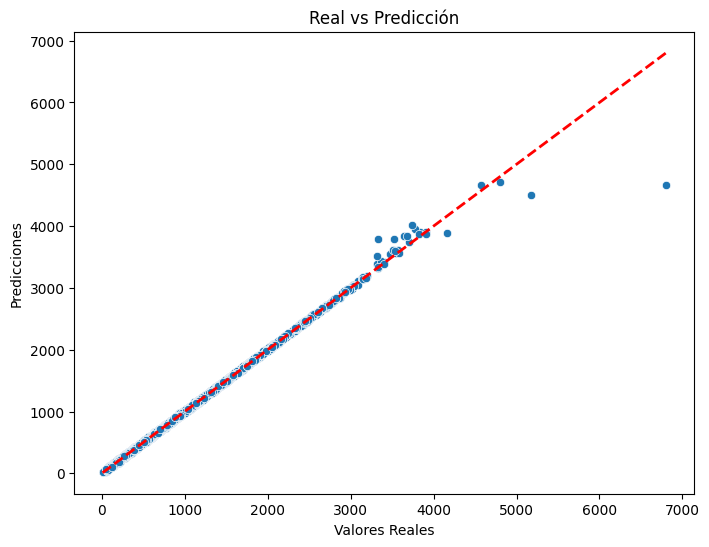

In [ ]:
y_pred = cross_val_predict(modelo, X, y, cv=5)

plt.figure(figsize=(8, 6))
sns.scatterplot(x=y, y=y_pred)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2)
plt.xlabel('Valores Reales')
plt.ylabel('Predicciones')
plt.title('Real vs Predicción')
plt.show()

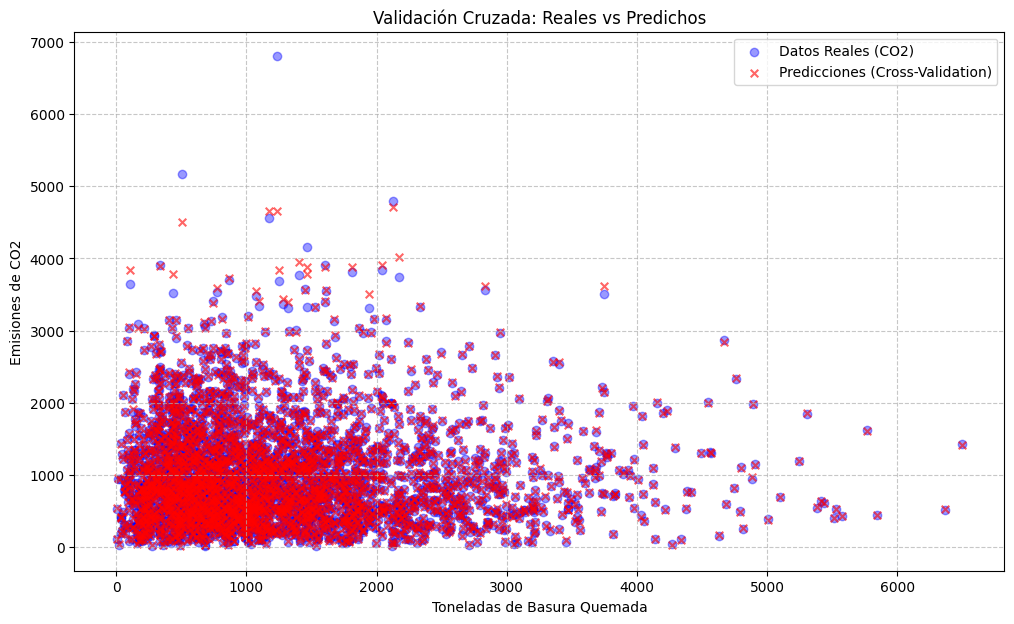

In [ ]:
y_pred_cv = cross_val_predict(modelo, X, y, cv=5)

plt.figure(figsize=(12, 7))
plt.scatter(df['Burned_Waste_Tons'], y, color='blue', alpha=0.4, label='Datos Reales (CO2)')
plt.scatter(df['Burned_Waste_Tons'], y_pred_cv, color='red', marker='x', s=30, alpha=0.6, label='Predicciones (Cross-Validation)')
plt.xlabel('Toneladas de Basura Quemada')
plt.ylabel('Emisiones de CO2')
plt.title(f'Validación Cruzada: Reales vs Predichos')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

plt.show()